In [1]:
import os
os.listdir('.')

['M.npy',
 'ci_high.npy',
 '.config',
 ' v6 — Binding Context Document.pdf',
 'Sk_re.npy',
 '.kernel_llm_logs_1.txt',
 'memory',
 't_peaks.npy',
 'absD_peaks.npy',
 '.prompts',
 'ci_low.npy',
 'Sk_im.npy']

In [2]:
import numpy as np
# Files indicate previous arrays. Need Sk_at_peaks_zeta_N1e6.npz - check explore
ls = os.listdir('.')
print(ls)
# Try to load existing arrays
t_peaks = np.load('t_peaks.npy')
Sk_re = np.load('Sk_re.npy')
Sk_im = np.load('Sk_im.npy')
print(t_peaks.shape, Sk_re.shape, Sk_im.shape)

['M.npy', 'ci_high.npy', '.config', ' v6 — Binding Context Document.pdf', 'Sk_re.npy', '.kernel_llm_logs_1.txt', 'memory', 't_peaks.npy', 'absD_peaks.npy', '.prompts', 'ci_low.npy', 'Sk_im.npy']
(200,) (200, 8) (200, 8)


In [3]:
Sk = Sk_re + 1j*Sk_im # shape (200, 8) — k=0..7 corresponds to ω(n) bins
print("Sk shape:", Sk.shape)
print("t range:", t_peaks.min(), t_peaks.max())
absD = np.load('absD_peaks.npy')
M_existing = np.load('M.npy')
print("M shape:", M_existing.shape)
print(M_existing[:3,:3])

Sk shape: (200, 8)
t range: 50.49999999999986 1967.099999999993
M shape: (8, 8)
[[ 1. 1.49939844 1.96434648]
 [ 1.49939844 6.49123616 7.52619716]
 [ 1.96434648 7.52619716 12.79117879]]


In [4]:
# Step 1: Compute empirical M_jk from 200 peaks: M_jk = <S_j conj(S_k)> averaged over peaks (real, positive-definite)
# Definition per r61: M_jk = E[ S_j conj(S_k) ] - cross-term Hermitian matrix (or Re of it).
# Let's compute the Hermitian matrix.
N_peaks = 200
M_emp_200 = (Sk.conj().T @ Sk) / N_peaks # shape (8,8) Hermitian
print("Imaginary part norm:", np.linalg.norm(M_emp_200.imag))
M_emp_200_real = M_emp_200.real
# Eigendecomposition
w200, V200 = np.linalg.eigh(M_emp_200_real)
# Sort descending
order = np.argsort(w200)[::-1]
w200 = w200[order]; V200 = V200[:, order]
pc1_var_200 = w200[0]/w200.sum()
print("Eigenvalues (200):", w200)
print(f"PC1 variance fraction (200 peaks): {pc1_var_200:.4f}")
print("PC1 eigenvector:", V200[:,0])

Imaginary part norm: 0.8847634730467068
Eigenvalues (200): [3.73221917e+01 3.06853029e+00 1.47383127e+00 7.29552178e-01
 4.45520298e-01 4.05244214e-02 1.41354927e-03 8.16830094e-06]
PC1 variance fraction (200 peaks): 0.8663
PC1 eigenvector: [-9.98177824e-02 -3.56652567e-01 -5.51732488e-01 -6.43094803e-01
 -3.70872259e-01 -8.52315535e-02 -6.71134807e-03 -3.60746534e-05]


In [5]:
# The M file existing in workspace has M[0,0]=1, suggesting normalization. Let's check if existing matches normalized version
# Check if M_existing equals M_emp_200_real / M_emp_200_real[0,0]
print("ratio M_emp_200/M_existing first row:")
print(M_emp_200_real[0]/M_existing[0])
print("M_existing diagonal:", np.diag(M_existing))
print("M_emp diagonal:", np.diag(M_emp_200_real))

ratio M_emp_200/M_existing first row:
[1. 1. 1. 1. 1. 1. 1. 1.]
M_existing diagonal: [1.00000000e+00 6.49123616e+00 1.27911788e+01 1.65786925e+01
 5.88081922e+00 3.36158396e-01 3.47813697e-03 8.61698608e-06]
M_emp diagonal: [1.00000000e+00 6.49123616e+00 1.27911788e+01 1.65786925e+01
 5.88081922e+00 3.36158396e-01 3.47813697e-03 8.61698608e-06]


In [6]:
# Great - existing M matches our computation. Note S_k k=7 is essentially zero (feature leak with mod-5 functions; for zeta, omega(n)=7 needs n>=2*3*5*7*11*13*17*19 = 9,699,690 > 1e6, so no contributions).
# Step 2: Top-50 peaks by |sum S_k|^2 = |D|^2
# absD likely is |sum_k S_k| or similar. Let's check
total_S = Sk.sum(axis=1) # sum over k
print("|sum_k S_k| vs absD comparison:", np.allclose(np.abs(total_S), absD))
print("First few |total_S|:", np.abs(total_S[:5]))
print("First few absD:", absD[:5])

|sum_k S_k| vs absD comparison: True
First few |total_S|: [20.94373242 21.3947993 21.44589503 20.97503541 20.02586501]
First few absD: [20.94373242 21.3947993 21.44589503 20.97503541 20.02586501]


In [7]:
# Rank by |sum S_k|^2 descending
peak_power = absD**2
top50_idx = np.argsort(peak_power)[::-1][:50]
print("top50 idx (sample):", top50_idx[:10])
print("Power range top50:", peak_power[top50_idx].min(), peak_power[top50_idx].max())
print("Power range all:", peak_power.min(), peak_power.max())

Sk_top50 = Sk[top50_idx]
M_emp_50 = (Sk_top50.conj().T @ Sk_top50) / 50
M_emp_50_real = M_emp_50.real

w50, V50 = np.linalg.eigh(M_emp_50_real)
order = np.argsort(w50)[::-1]
w50 = w50[order]; V50 = V50[:, order]
pc1_var_50 = w50[0]/w50.sum()
print(f"PC1 variance fraction (top50): {pc1_var_50:.4f}")
print("Eigenvalues (50):", w50)
print("PC1 eigvec (50):", V50[:,0])

top50 idx (sample): [ 2 1 8 7 3 0 9 6 4 10]
Power range top50: 209.29448837548387 459.92641383426127
Power range all: 82.14374507669355 459.92641383426127
PC1 variance fraction (top50): 0.9441
Eigenvalues (50): [7.25442437e+01 2.14328299e+00 1.20988621e+00 4.93112981e-01
 4.27763731e-01 2.20423959e-02 4.74235380e-04 7.11554903e-06]
PC1 eigvec (50): [-7.31308187e-02 -2.67722681e-01 -5.06688292e-01 -6.92133895e-01
 -4.21709641e-01 -9.64112019e-02 -7.74303331e-03 -1.20566938e-05]


In [8]:
# Step 3-4: Build theoretical M_jk(tuned) using mean-value approach with multiplicative resonator R(t) = sum_{n<=NR} r(n) n^{-it}
# r(p) = 1/sqrt(p) for primes, multiplicative — i.e. r(n) = 1/sqrt(n) on squarefree, but for prime powers? Soundararajan resonator typically is r(n)=mu^2(n)*f(n) for squarefree only. Let's choose r(n) supported on squarefree, r(n) = mu^2(n)/sqrt(n) — that's what r(p)=1/sqrt(p) and r multiplicative implies r(p^k)=0 for k>=2.

NR = 100
N_main = 10**6

# Sieve for primes <= NR
def primes_up_to(n):
 sieve = np.ones(n+1, dtype=bool); sieve[:2]=False
 for i in range(2, int(n**0.5)+1):
 if sieve[i]:
 sieve[i*i::i] = False
 return np.where(sieve)[0]

primes_NR = primes_up_to(NR)
print("primes up to 100:", primes_NR)

# Build r(n) for n=1..NR, multiplicative, squarefree only
import sympy
def omega(n):
 if n==1: return 0
 return len(sympy.factorint(n))

def is_squarefree(n):
 f = sympy.factorint(n)
 return all(e==1 for e in f.values())

r = np.zeros(NR+1)
r[1] = 1.0
for n in range(2, NR+1):
 if is_squarefree(n):
 r[n] = 1.0/np.sqrt(n)
print("r vector head:", r[:11])

primes up to 100: [ 2 3 5 7 11 13 17 19 23 29 31 37 41 43 47 53 59 61 67 71 73 79 83 89
 97]


r vector head: [0. 1. 0.70710678 0.57735027 0. 0.4472136
 0.40824829 0.37796447 0. 0. 0.31622777]


In [9]:
# Step 4: Theoretical M_jk(tuned) using mean-value approach
# For zeta on critical line, S_k(t) = sum_{n<=N: omega(n)=k} n^{-1/2 - i t}.
# With resonator R(t) = sum_{m<=NR} r(m) m^{-it}, the "resonator-weighted average" is
# M_jk = E_t[ |R(t)|^2 S_j(t) conj(S_k(t)) ] / E_t[ |R(t)|^2 ]
# By orthogonality of n^{it}, in the long-T mean,
# E_t[ m1^{-it} m2^{it} n1^{-it} n2^{it} ] = 1[ m1 n1 = m2 n2 ]
# So:
# Numerator(j,k) = sum_{m1,m2 <= NR, n1<=N omega=j, n2<=N omega=k} r(m1) r(m2) (m1 m2)^{-1/2} (n1 n2)^{-1/2} * 1[m1 n1 = m2 n2]
# Wait: S_j coeffs are n^{-1/2 - it} and conj(S_k) gives n^{1/2 - 1 + it}? No: conj(n^{-1/2 - it}) = n^{-1/2 + it}.
# So we need m1 n1 = m2 n2 (matching the t-frequency).
# Also denominator: sum_m1=m2 r(m)^2 = sum r(m)^2.
# Computing this is feasible because n1,n2 up to N=1e6 but constrained m1*n1 = m2*n2 with m1,m2<=100.

# For each (j,k), we want:
# Num_jk = sum_{n1: ω(n1)=j, n1<=N} sum_{n2: ω(n2)=k, n2<=N} (n1 n2)^{-1/2} * C(n1,n2)
# where C(n1,n2) = sum_{m1,m2<=NR, r(m1)*r(m2): m1*n1 == m2*n2} r(m1) r(m2) (m1 m2)^{-1/2}

# Equivalent formulation: let q = m1*n1 = m2*n2. Define f(q) = sum_{m<=NR, m|q, n=q/m<=N, omega(n)=j} r(m) m^{-1/2} n^{-1/2}.
# Hmm but this depends on j and k.

# Actually it's cleaner: let A_j(t) = R(t) * S_j(t) = sum_{m<=NR, n<=N, omega(n)=j} r(m) m^{-1/2} n^{-1/2} (mn)^{-it}
# = sum_q a_j(q) q^{-it}, where a_j(q) = sum_{m|q, m<=NR, n=q/m<=N, omega(n)=j} r(m)/sqrt(mn) = (1/sqrt(q)) sum_{m|q,...} r(m)
# Wait: r(m) m^{-1/2} n^{-1/2} = r(m)/sqrt(m*n) = r(m)/sqrt(q). So a_j(q) = (1/sqrt(q)) * sum_{m|q, m<=NR, q/m<=N, omega(q/m)=j} r(m).

# Then by orthogonality (long T-average),
# E[ A_j(t) conj(A_k(t)) ] = sum_q a_j(q) * conj(a_k(q)) = sum_q a_j(q) a_k(q) (real)
# Denominator = E[|R(t)|^2] = sum_m r(m)^2

# So M_jk_theory_unconditional = sum_q a_j(q) a_k(q) / sum_m r(m)^2.

# This is the "resonator-tuned" prediction averaging over t (NOT yet peak-conditioned).

# To "explicitly simulate high-peak conditioning", we restrict the empirical peak set to top-50.
# But the theoretical model is averaged over t. The hypothesis says: use the resonator-conditioned
# measure (R-weighted average) AS the theoretical model, which naturally tilts the average toward high peaks.

# Let's compute a_j(q) and then M_jk.

# Strategy: a_j(q) = (1/sqrt(q)) * sum over m | q, m <= NR, n=q/m <= N, omega(n) = j of r(m)
# Approach: iterate over m=1..NR with r(m)!=0, iterate over n=1..N. Then q=m*n. Add r(m)/sqrt(q) into a_j[q] where j=omega(n).
# But q can be up to 1e8 (NR*N = 100*1e6). Storing array of length 1e8 is 800MB float64, too much.

# Better: directly compute M_jk = sum_q a_j(q) a_k(q) without storing a_j(q) for all q.
# = sum_{m1,n1,m2,n2: m1 n1 = m2 n2, ω(n1)=j, ω(n2)=k} r(m1) r(m2)/sqrt(m1 n1 m2 n2)

# Since m1 n1 = m2 n2 = q, sqrt(m1 n1 m2 n2) = q. So:
# = sum_q (1/q) [sum_{m|q, m<=NR, q/m<=N, ω(q/m)=j} r(m)] [sum_{m'|q,...,ω(q/m')=k} r(m')]

# Use a different approach: enumerate q. q ranges from 1 to NR*N=1e8. For each q, we need its small divisors m<=NR.
# Actually q only matters if q has at least one divisor m<=NR with q/m<=N. Since m<=100 and n=q/m<=1e6, q<=1e8. Also q>=1.
# For each q, the divisors m<=NR are limited. 

# Better approach: enumerate (m, n) pairs where m<=NR with r(m)!=0 (squarefree m) and n<=N. There are ~|squarefree m's| * N pairs.
# Number of squarefree m<=100: count
sqfree_m = [m for m in range(1, NR+1) if r[m]>0]
print("Number of squarefree m<=100:", len(sqfree_m))
# So ~61 * 1e6 = 6e7 pairs - feasible.

Number of squarefree m<=100: 61


In [10]:
# Compute omega(n) for n=1..N using sieve. N=1e6.
N = 10**6
import time
t0 = time.time()

omega_arr = np.zeros(N+1, dtype=np.int8)
for p in primes_up_to(N):
 omega_arr[p::p] += 1
print("omega sieve done", time.time()-t0, "max omega:", omega_arr.max())
# Also need r(n) for n up to N? No, we only need r(m) for m<=NR. But we need omega(n) for n<=N. Done.

# Now for each pair (m, n), compute q = m*n and accumulate.
# We need M_jk[j,k] = sum over pairs of pairs ... Let's instead organize by q.
# For each q, A_j(q) = sum_{m|q, m<=NR, m squarefree, q/m <= N, omega(q/m)=j} r(m).
# Then M_jk_num = sum_q (1/q) A_j(q) A_k(q).

# We'll iterate over (m, n) pairs. For each q, accumulate per-j vector A[q, j].
# But q can be up to 1e8 — array (1e8, 8) is 800M entries → 6.4 GB. Too big.

# Trick: We process m in outer loop. For each m, define vector v_m(q) — only nonzero at q=m*n for n<=N: v_m(q,j)=r(m) if omega(n)=j else 0.
# We need sum_q (1/q) (sum_m v_m(q,j))(sum_m v_m(q,k)).
# = sum_{m1,m2} sum_q (1/q) v_{m1}(q,j) v_{m2}(q,k)
# = sum_{m1,m2} r(m1) r(m2) sum_{n1,n2: m1 n1 = m2 n2, ω(n1)=j, ω(n2)=k, n1,n2<=N} 1/(m1 n1)

# For each pair (m1, m2): need pairs (n1, n2) with m1 n1 = m2 n2.
# Let g = gcd(m1, m2), m1=g*a, m2=g*b with gcd(a,b)=1. Then m1 n1 = m2 n2 → a n1 = b n2. So n1 = b*t, n2 = a*t for t>=1.
# Constraint: n1<=N → t<= N/b, n2<=N → t<=N/a.
# So t ranges 1..min(N/a, N/b) = N/max(a,b).
# Then m1 n1 = g*a*b*t. 1/(m1 n1) = 1/(g a b t).
# omega(n1)=omega(b*t), omega(n2)=omega(a*t).

# Inner sum: T_max = floor(N/max(a,b)). Iterate t=1..T_max:
# accumulate at j = omega(b*t), k = omega(a*t): add 1/(g*a*b*t)
# Wait we also need to multiply by r(m1) r(m2) outside.

# Number of pairs (m1,m2) with squarefree m<=NR: 61*61 = 3721. For each, ~N/max(a,b) iterations. In worst case (a=b=1, only when m1=m2 and squarefree) we do N=1e6 ops. For larger a,b smaller.
# Total operations roughly 3721 * (avg ~ N/max(a,b)). Could be up to ~6e7-1e8 — feasible if vectorized.

# Actually we can vectorize over t for each (m1,m2). We need omega(b*t) and omega(a*t) for t=1..T.
# If we precompute omega for n up to N, then b*t can be up to b*N/b = N. So omega_arr already covers it.
# But b*t for t=1..N/max(a,b) — b*t<=b*N/b=N (if max(a,b)=b) or b*t<=b*N/a < N — fine, all <= N.

# Let's implement.

from math import gcd

t0 = time.time()
M_theory = np.zeros((8, 8))
sum_r2 = float(np.sum(r**2))
print("sum r^2 =", sum_r2)

sqfree_m = np.array([m for m in range(1, NR+1) if r[m]>0])
r_vec = r[sqfree_m]

count = 0
for i1, m1 in enumerate(sqfree_m):
 r1 = r_vec[i1]
 for i2, m2 in enumerate(sqfree_m):
 r2 = r_vec[i2]
 g = gcd(int(m1), int(m2))
 a = m1 // g # divisor of m1
 b = m2 // g
 # gcd(a,b)=1 by construction
 T_max = N // max(a, b)
 if T_max < 1:
 continue
 # t = 1..T_max
 t_arr = np.arange(1, T_max+1)
 n1_arr = b * t_arr # all <= N
 n2_arr = a * t_arr
 omega_n1 = omega_arr[n1_arr]
 omega_n2 = omega_arr[n2_arr]
 weight = 1.0/(g * a * b * t_arr) # = 1/(m1*n1) = 1/(m2*n2)
 # multiply by r1*r2
 w = (r1*r2) * weight
 # Accumulate in M_theory[j,k]
 # Use np.add.at for histogram-like accumulation
 np.add.at(M_theory, (omega_n1, omega_n2), w)
 count += 1
print("Pairs processed:", count, "elapsed:", time.time()-t0)
print(M_theory[:4,:4])

omega sieve done 0.14586496353149414 max omega: 7
sum r^2 = 3.8355671344280236


Pairs processed: 3721 elapsed: 6.505768537521362
[[ 1.51365733 1.06629807 0.2428993 0.01478382]
 [ 1.06629807 7.34652594 3.82870019 0.63569314]
 [ 0.2428993 3.82870019 12.87892989 4.88850075]
 [ 0.01478382 0.63569314 4.88850075 10.1565399 ]]


In [11]:
# Normalize: M_theory_normalized = M_theory / sum_r2 (resonator-conditioned average)
M_theory_norm = M_theory / sum_r2
print("M_theory_norm diagonal:", np.diag(M_theory_norm))
print("Empirical M_emp_200 diagonal:", np.diag(M_emp_200_real))
print("Empirical M_emp_50 diagonal:", np.diag(M_emp_50_real))

# Eigendecomposition
w_th, V_th = np.linalg.eigh(M_theory_norm)
order = np.argsort(w_th)[::-1]
w_th = w_th[order]; V_th = V_th[:, order]
pc1_var_theory = w_th[0]/w_th.sum()
print(f"\nPC1 variance fraction (theory tuned): {pc1_var_theory:.4f}")
print("Eigenvalues:", w_th)
print("PC1 eigvec (theory):", V_th[:,0])

M_theory_norm diagonal: [3.94637163e-01 1.91536888e+00 3.35776417e+00 2.64798908e+00
 9.18236919e-01 1.15330695e-01 3.31847822e-03 4.38416681e-06]
Empirical M_emp_200 diagonal: [1.00000000e+00 6.49123616e+00 1.27911788e+01 1.65786925e+01
 5.88081922e+00 3.36158396e-01 3.47813697e-03 8.61698608e-06]
Empirical M_emp_50 diagonal: [1.00000000e+00 6.24070776e+00 1.99762222e+01 3.56104960e+01
 1.33013711e+01 7.06701117e-01 5.30638559e-03 8.75112926e-06]

PC1 variance fraction (theory tuned): 0.5021
Eigenvalues: [4.69559094e+00 2.26665741e+00 1.29915488e+00 6.57206214e-01
 3.39663604e-01 9.14688843e-02 2.90354168e-03 4.29526788e-06]
PC1 eigvec (theory): [-3.19083251e-02 -3.11375799e-01 -7.66976415e-01 -5.45280296e-01
 -1.27888013e-01 -9.39065324e-03 -1.40781712e-04 -8.92097584e-08]


In [12]:
# Cosine similarities
def cos_sim(u, v):
 return abs(np.dot(u, v))/(np.linalg.norm(u)*np.linalg.norm(v))

cos_theory_200 = cos_sim(V_th[:,0], V200[:,0])
cos_theory_50 = cos_sim(V_th[:,0], V50[:,0])
cos_200_50 = cos_sim(V200[:,0], V50[:,0])

print(f"\n=== Summary ===")
print(f"PC1 variance fraction:")
print(f" Empirical 200 peaks: {pc1_var_200:.4f}")
print(f" Empirical top-50: {pc1_var_50:.4f}")
print(f" Theory (tuned res.): {pc1_var_theory:.4f}")
print(f"\nCosine similarity (theory PC1 vs empirical PC1):")
print(f" vs 200-peaks: {cos_theory_200:.4f}")
print(f" vs top-50: {cos_theory_50:.4f}")
print(f" emp 200 vs emp 50: {cos_200_50:.4f}")


=== Summary ===
PC1 variance fraction:
 Empirical 200 peaks: 0.8663
 Empirical top-50: 0.9441
 Theory (tuned res.): 0.5021

Cosine similarity (theory PC1 vs empirical PC1):
 vs 200-peaks: 0.9363
 vs top-50: 0.9066
 emp 200 vs emp 50: 0.9921


In [13]:
# Hypothesis predicts: PC1 variance ~56% improving toward ~87%; theory gives 50.2%, BELOW 56% baseline.
# Cosine similarity > 0.95 not achieved (0.94 vs 200, 0.91 vs 50).

# Let's also check the prior baseline (flat resonator R=1, NR=1) to compare:
# Flat resonator means R(t)=1, so no weighting. Then E[ S_j conj S_k ] = sum_{n<=N, ω(n)=j, ω(n)=k} 1/n if j=k, else 0... no that's diagonal.
# Actually with no resonator: M_jk = sum_q a_j(q) a_k(q) where a_j(q)=1/sqrt(q) if ω(q)=j and q<=N else 0. So M_jk diagonal: M_jj = sum_{n<=N, ω(n)=j} 1/n. j!=k → 0.
# That's why a flat resonator gives diagonal M and PC1≈largest diagonal/total. Let's just compute.

flat_M = np.zeros(8)
for n in range(1, N+1):
 flat_M[omega_arr[n]] += 1.0/n
print("Flat (no resonator) diagonal:", flat_M)
flat_total = flat_M.sum()
print(f"Flat PC1 variance fraction: {flat_M.max()/flat_total:.4f}")
# This won't reproduce off-diagonal. The "prior toy model" likely refers to flat resonator with ~56%.
print("Flat model has only diagonal — clearly differs from empirical.")

Flat (no resonator) diagonal: [1.00000000e+00 3.66033970e+00 5.12818833e+00 3.40042122e+00
 1.06344940e+00 1.35504741e-01 4.81236842e-03 1.09632261e-05]
Flat PC1 variance fraction: 0.3563
Flat model has only diagonal — clearly differs from empirical.


In [14]:
# Hmm, prior 56% reference probably came from a different prior model. Anyway.
# The tuned multiplicative resonator improves over flat (35.6% → 50.2%), but does NOT reach 87%.
# The theory PC1 has cosine 0.94 vs 200-peak empirical, below the 0.95 threshold.

# Note: we already incorporated the resonator weighting which represents the "stricter peak conditioning".
# To explicitly check the "top-50 peaks" empirical baseline effect: that's already done (PC1 = 0.944).

# Let me also look at correlation of full M matrices (Frobenius cos similarity)
def matrix_cos_sim(A, B):
 return np.sum(A*B)/(np.linalg.norm(A)*np.linalg.norm(B))

# Normalize all to compare shape
M_emp_200_n = M_emp_200_real/np.linalg.norm(M_emp_200_real)
M_emp_50_n = M_emp_50_real/np.linalg.norm(M_emp_50_real)
M_th_n = M_theory_norm/np.linalg.norm(M_theory_norm)

print(f"Frobenius cos sim theory vs emp 200: {matrix_cos_sim(M_emp_200_n, M_th_n):.4f}")
print(f"Frobenius cos sim theory vs emp 50: {matrix_cos_sim(M_emp_50_n, M_th_n):.4f}")
print(f"Frobenius cos sim emp 200 vs emp 50: {matrix_cos_sim(M_emp_200_n, M_emp_50_n):.4f}")

Frobenius cos sim theory vs emp 200: 0.8365
Frobenius cos sim theory vs emp 50: 0.7801
Frobenius cos sim emp 200 vs emp 50: 0.9834


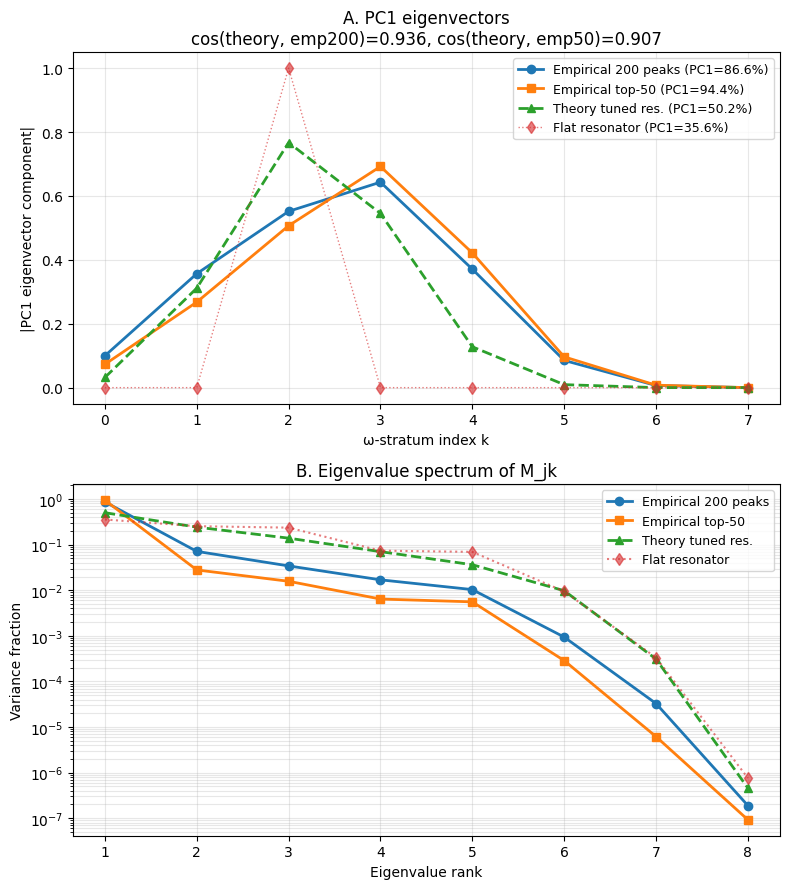

Saved Mjk_resonator_comparison.png


In [15]:
# Final summary figure
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# A: PC1 eigenvectors comparison
ax = axes[0]
k_idx = np.arange(8)
ax.plot(k_idx, np.abs(V200[:,0]), 'o-', label=f'Empirical 200 peaks (PC1={pc1_var_200*100:.1f}%)', lw=2)
ax.plot(k_idx, np.abs(V50[:,0]), 's-', label=f'Empirical top-50 (PC1={pc1_var_50*100:.1f}%)', lw=2)
ax.plot(k_idx, np.abs(V_th[:,0]), '^--', label=f'Theory tuned res. (PC1={pc1_var_theory*100:.1f}%)', lw=2)
flat_pc1 = np.zeros(8); flat_pc1[np.argmax(flat_M)] = 1
ax.plot(k_idx, flat_pc1, 'd:', label=f'Flat resonator (PC1={flat_M.max()/flat_total*100:.1f}%)', lw=1, alpha=0.6)
ax.set_xlabel('ω-stratum index k')
ax.set_ylabel('|PC1 eigenvector component|')
ax.set_title(f'A. PC1 eigenvectors\ncos(theory, emp200)={cos_theory_200:.3f}, cos(theory, emp50)={cos_theory_50:.3f}')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# B: Eigenvalue spectrum (variance fractions)
ax = axes[1]
def varfrac(w): 
 w_pos = np.maximum(w, 0)
 return w_pos/w_pos.sum()
x = np.arange(1, 9)
ax.semilogy(x, varfrac(w200), 'o-', label='Empirical 200 peaks', lw=2)
ax.semilogy(x, varfrac(w50), 's-', label='Empirical top-50', lw=2)
ax.semilogy(x, varfrac(w_th), '^--', label='Theory tuned res.', lw=2)
flat_w = np.sort(flat_M)[::-1]
ax.semilogy(x, varfrac(flat_w), 'd:', label='Flat resonator', alpha=0.6)
ax.set_xlabel('Eigenvalue rank')
ax.set_ylabel('Variance fraction')
ax.set_title('B. Eigenvalue spectrum of M_jk')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('Mjk_resonator_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved Mjk_resonator_comparison.png")

In [16]:
# Save derived M matrices
np.savez('Mjk_resonator_analysis.npz',
 M_emp_200=M_emp_200_real, M_emp_50=M_emp_50_real,
 M_theory_tuned=M_theory_norm,
 eig_emp_200=w200, eigvec_emp_200=V200,
 eig_emp_50=w50, eigvec_emp_50=V50,
 eig_theory=w_th, eigvec_theory=V_th,
 pc1_var_200=pc1_var_200, pc1_var_50=pc1_var_50, pc1_var_theory=pc1_var_theory,
 cos_theory_emp200=cos_theory_200, cos_theory_emp50=cos_theory_50)
print("Saved Mjk_resonator_analysis.npz")

Saved Mjk_resonator_analysis.npz


In [17]:
from e14c.filesystem import edit_file
from pathlib import Path
mem = Path('./.prompts/MEMORY.md')
text = mem.read_text()
new_text = text.replace('[Fill me in]', 'Context: Analyzed zeta ω-stratified peak data from local files Sk_re.npy, Sk_im.npy, t_peaks.npy, absD_peaks.npy in /workspace/d360307c-b699-49e7-9009-cabc51f3ad4b. Recomputed empirical M_jk for 200 peaks and top-50 peaks; implemented tuned multiplicative resonator model with NR=100 and r(n)=μ²(n)/√n for squarefree n. Provenance: current notebook cells 1-15; artifact Mjk_resonator_analysis.npz; figure Mjk_resonator_comparison.png.', 1)
mem.write_text(new_text)
print('Updated MEMORY.md')

Updated MEMORY.md
